In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
plt.rc('font', family='NanumBarunGothic')
plt.rc('axes', unicode_minus=False)

In [ ]:
ds = pd.read_csv("/content/drive/MyDrive/소비 유형.csv", encoding='utf-8-sig')
ds.head()

,프로그램유형,2023년(%),2024년(%),2025년(%)
0,숏폼,58.1,70.7,78.9
1,OTT 자체 제작 프로그램,55.4,54.3,68.6
2,유료방송 채널 제작 프로그램,41.8,38.0,42.0
3,지상파방송 채널 제작 프로그램,29.2,31.9,30.3
4,영화,28.0,34.7,29.9


In [ ]:
short_names = {
    '숏폼': '숏폼',
    'OTT 자체 제작 프로그램': 'OTT 오리지널',
    '유료방송 채널 제작 프로그램': '유료방송',
    '지상파방송 채널 제작 프로그램': '지상파',
    '영화': '영화',
    '다른 제작 형태의 프로그램(숏폼 제외)': '기타 형태'
}
ds['프로그램유형'] = ds['프로그램유형'].map(short_names)

In [ ]:
ds = ds.sort_values(by='2025년(%)', ascending=False)

ds_melted = ds.melt(id_vars='프로그램유형',
                    value_vars=['2023년(%)', '2024년(%)', '2025년(%)'],
                    var_name='연도',
                    value_name='퍼센트')

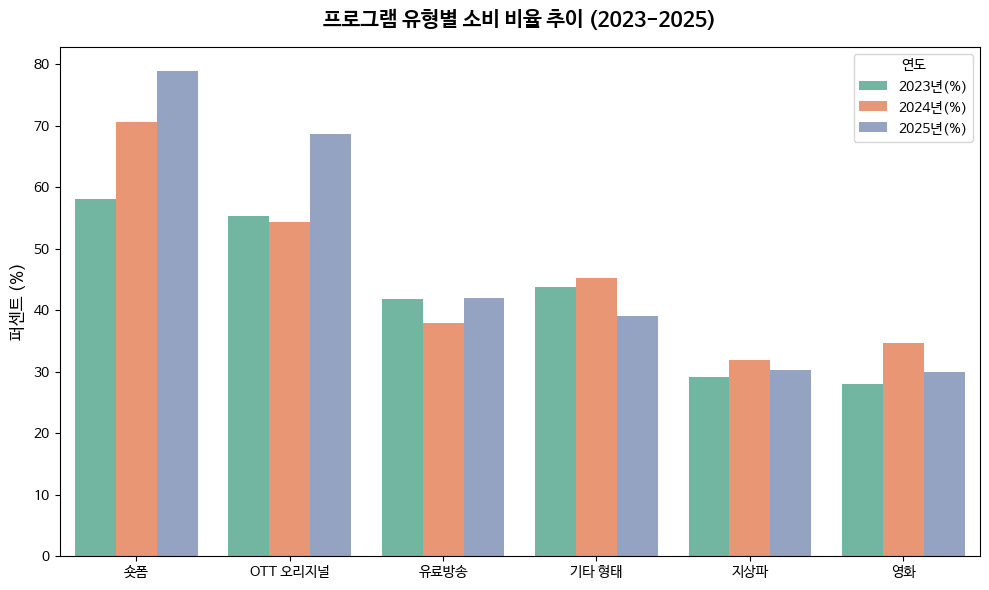

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=ds_melted, x='프로그램유형', y='퍼센트', hue='연도', palette='Set2')

# 가로축 하단의 모든 지저분한 텍스트 파편 강제 삭제
ax.set_xlabel('')
ax.xaxis.get_label().set_visible(False)

# 제목 및 세로축 레이블 설정
plt.title('프로그램 유형별 소비 비율 추이 (2023-2025)', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('퍼센트 (%)', fontsize=12)

# 가로축 항목 글자는 똑바로 나오게 고정
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()